# Homework 8 - Chapter 13

- Due Date: Monday, April 6th no later than 11:59 p.m.
- Partner Information: You may complete this assignment individually or with exactly one classmate.
- Submission Instructions (working alone): Upload your solution, entitled **YourFirstName-YourLastName-Homework8.ipynb** to the Canvas Homework 8 Dropbox.
- Submission Instructions (working with one classmate): Upload your solution, entitled **YourFirstName-YourLastName-PartnerFirstName-PartnerLastName-Homework8.ipynb** to the Canvas Homework 8 Dropbox. Note: If you work with a partner, only one person needs to submit a solution. If you both submit a solution, the submission that will be graded is the one from the partner whose last name comes alphabetically first.
- Deadline Reminder: Once the submission deadline passes, Canvas will no longer accept your submission and you will no longer be able to earn credit. 
Thus, if you are not able to fully complete the assignment, submit whatever you have before the deadline so that partial credit can be earned.

## Starting Code

In [2]:
from datascience import *
import matplotlib.pyplot as plots
import numpy as np
%matplotlib inline

Download the file [education2023.csv]()
into the same directory as this Jupyter notebook.

In [3]:
# Place the csv file in the same directory as your solution
education = Table().read_table("education2023.csv")
education

FIPS Code,State,Area name,Bachelors Percent
1001,AL,Autauga County,28.2827
1003,AL,Baldwin County,32.7976
1005,AL,Barbour County,11.4647
1007,AL,Bibb County,11.4682
1009,AL,Blount County,15.579
1011,AL,Bullock County,8.99973
1013,AL,Butler County,13.7648
1015,AL,Calhoun County,20.5451
1017,AL,Chambers County,14.585
1019,AL,Cherokee County,15.945


## Question 1 - 1 Point

Government work is a key field for data scientists, as accurate data is essential for effective policy-making and informed analysis of national, state, or local conditions. One of the largest collectors of data in America is the U.S Census Bureau, an organization that strives to provide detailed information about the population of the country.

You have been selected to analyze the percent of the population with a bachelor's degree across U.S. counties. The Census Bureau expects the median percentage to be 25%. What are the null ($H_0$) and alternative ($H_a$) hypotheses of this study?

**Null Hypothesis ($H_0$):** The median percentage of people with bachelor degrees across each county is 25%. 

**Alternative Hypothesis ($H_a$):** The median percentage of people with bachelor degrees across counties is not 25%.

## Question 2 - 2 Points

The Census Bureau initially wants to explore the distribution of county-level bachelor’s degree completion rates. Create a histogram using the **Bachelors Percent** column from the dataset. The histogram should have bins ranging from 0 to 100, with intervals of 5 percentage points. To highlight the spread of the data, plot two red vertical dashed lines at the 25th percentile and 75th percentile.  (Hint: Use the [MatPlotLib](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvline.html) documentation as a reference)

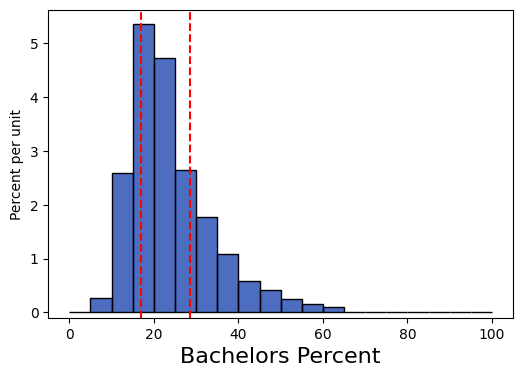

In [5]:
education.hist("Bachelors Percent", bins=np.arange(0,105,5))
plots.ylim(-.001)
plots.axvline(np.percentile(education.column("Bachelors Percent"), 25),color='r', linestyle="--")
plots.axvline(np.percentile(education.column("Bachelors Percent"), 75),color='r', linestyle="--")


## Question 3 - 1 Point (2 parts)

The Census Bureau prefers not to use the entire dataset when analyzing problems in order to save time and computational resources. Create a table called **education_sample** by sampling the original dataset without replacement 750 times. Then, display this table's **Bachelor Percent** column as a histogram, using bins ranging from 0 to 100 in intervals of 5.

(-0.001, 0.05516)

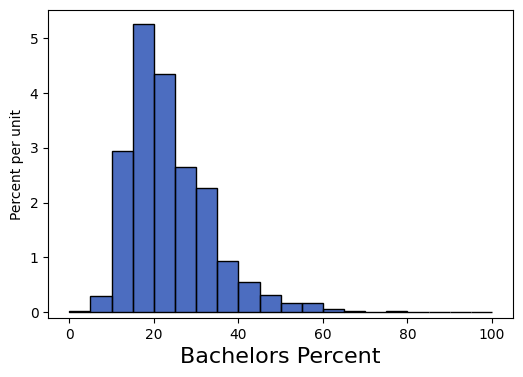

In [6]:
education_sample = education.sample(750, with_replacement=False)
education_sample.hist("Bachelors Percent", bins=np.arange(0,105,5))
plots.ylim(-.001)

What principle from Chapter 13 explains why this distribution is similar to the population distribution?

**Answer** - The distribution of this sample resembles the distribution of the population because of the law of averages. This is the fundimental idea of why a bootstrap works.

## Question 4a - 2 Points

To estimate the median percentage of county populations with a bachelor’s degree, perform a bootstrap simulation using **education_sample**. First, create a function that samples 750 rows (the sample size) from **education_sample** with replacement, then returns the median of the sampled **Bachelors Percent** values. Write a second function that calls the first function 2,500 times, storing each median in an array and then returning the array. Utilize these two functions to display a histogram of the median values, as well as a 99% confidence interval represented by a yellow line along the bottom of the histogram.

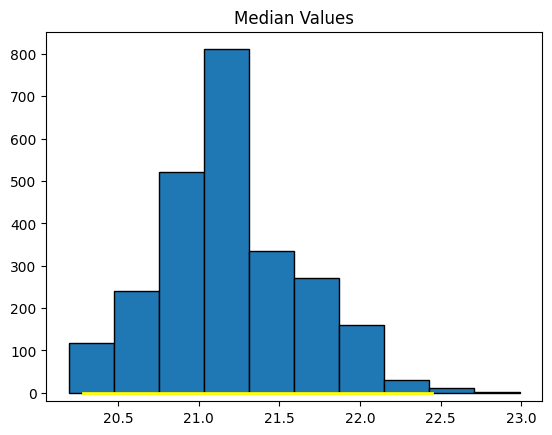

In [7]:
def one_bootstrap():
    bootstrap = education_sample.sample(750, with_replacement=True)
    return (np.percentile(bootstrap.column("Bachelors Percent"), 50))

def many_bootstraps():
    bootstrap_medians = make_array()
    for _ in range(2500):
        bootstrap_medians = np.append(bootstrap_medians, one_bootstrap())
    return bootstrap_medians

vals = many_bootstraps()
plots.hist(vals)
plots.title("Median Values")
plots.ylim(-20)
left = percentile(.5, vals)
right = percentile(99.5, vals)
plots.plot([left, right],[0,0], color="yellow", lw=2)

## Question 4b - 1 Point

If a 90% confidence interval was used instead of a 99% confidence interval, would the range covered grow smaller or larger? Explain your answer.

**Answer** - If we used a 90% confidence interval instead of a 99% confidence interval we would see the ranges covered shrink. This behavior is expected because as we lower the confidence level, we accept a greater chance of missing the true median, so the margin of error decreases and the interval becomes narrower.

## Question 5 - 1 Point

Would the null hypothesis ($H_0$) from question 1 be accepted or rejected if a 1% level of significance was used? Explain your answer.

**Answer** - If 1% significance was used, we will reject the null hypothesis. The null indicates that the percentage of graduating with a bachelors is 25%, but as we can see above, 25% does not fall within the 99% confidence interval (1% level of significance) which is why we are rejecting the null hypothesis.

## Question 6 - 2 Points

Develop an insightful visualization that uses the provided csv file, Chapter 13 knowledge, 
and any other data science knowledge that you have previously learned.  Explain your visualization 
and what makes it insightful.

95% CI: [22.28%, 27.53%]


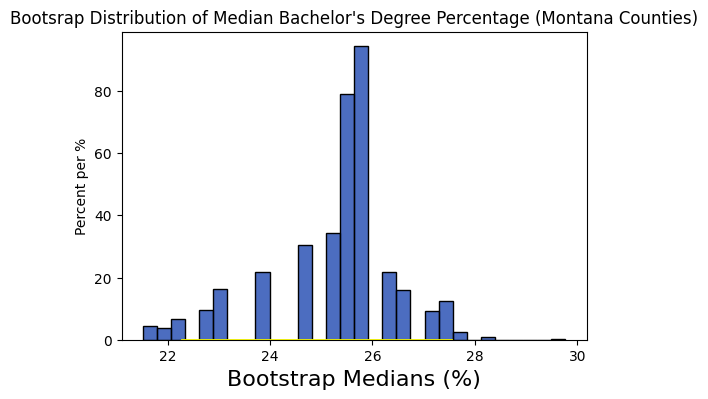

In [10]:
# Place visualization code here.
# Load data
import numpy as np
from datascience import *

# Load data
counties = Table.read_table('education2023.csv')

# Group by county name, take the mean Bachelors Percent per county
grouped = counties.where("State", "MT")

# Bootstrap on the grouped data
boot_medians = make_array()
for _ in np.arange(2000):
    resampled = grouped.sample(with_replacement=True)
    boot_medians = np.append(boot_medians, percentile(50, resampled.column('Bachelors Percent')))

left  = percentile(2.5,  boot_medians)
right = percentile(97.5, boot_medians)

print(f"95% CI: [{left:.2f}%, {right:.2f}%]")

# Plot
Table().with_column('Bootstrap Medians', boot_medians).hist(
    'Bootstrap Medians', bins=30, unit='%'
)
plots.plot([left, right],[0,0], color="yellow", lw=2)
plots.title("Bootsrap Distribution of Median Bachelor's Degree Percentage (Montana Counties)")
plots.show()

**Explanation -** By bootstrapping both Montana alone and the full US dataset (from the figure in question 4a), the visualization reveals that Montana counties are better educated than the national median suggests, while also showing that smaller samples produce wider, less certain confidence intervals.